<a href="https://colab.research.google.com/github/raul0807/Algorithms-for-massive-data-project/blob/main/Garbage_Recognizer_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os

# Defining the variable for the download
token = "KGAT_9efc02091cde2962df4a38c4b09852e7"
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/sumn2u/garbage-classification-v2"
zip_filename = "garbage.zip"

print("Starting the download of the dataset...")

# using curl for download the file
os.system(f'curl -L -H "Authorization: Bearer {token}" -o {zip_filename} {dataset_url}')

print("Download done. Extraction is starting...")

# extractn the zip file
!unzip -q {zip_filename} -d garbage_data

print("The dataset is ready in the directory: 'garbage_data'.")

Starting the download of the dataset...
Download done. Extraction is starting...
replace garbage_data/original/battery/battery_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: The dataset is ready in the directory: 'garbage_data'.


In [10]:
import os
import shutil
from PIL import Image

folder_path = "garbage_data/original"
removed = 0

print("Finding phantom directories...")
for root, dirs, files in os.walk(folder_path):
    for d in dirs:
        if d == ".ipynb_checkpoints":
            path_to_delete = os.path.join(root, d)
            shutil.rmtree(path_to_delete)
            print(f"Deleted system folder: {path_to_delete}")

print("Find file that are not images...")
for root, dirs, files in os.walk(folder_path):
    for file in files:
        file_path = os.path.join(root, file)

        # Delete everything that don't seem an image
        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            print(f"Deleted suspicious file: {file}")
            os.remove(file_path)
            removed += 1
            continue

        # control on corrupted images
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            print(f"Eliminated corrupted image: {file}")
            os.remove(file_path)
            removed += 1

print(f"\nCleaning completed. Deleted {removed} file gatecrashers")

Finding phantom directories...
Find file that are not images...

Cleaning completed. Deleted 0 file gatecrashers


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models


# Settings and scalability

DATA_DIR = "garbage_data/original"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Uploading data...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} TRUE classes: {class_names}")

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)


# DATA AUGMENTATION & PREPROCESSING

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])


# Creations of the CNN

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Training

print("\nStarting...")
EPOCHS = 10

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)
print("Done")

Uploading data...
Found 12257 files belonging to 10 classes.
Using 9806 files for training.
Found 12257 files belonging to 10 classes.
Using 2451 files for validation.
Found 10 TRUE classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

Starting...
Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.2330 - loss: 2.1326 - val_accuracy: 0.3452 - val_loss: 1.8396
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.3523 - loss: 1.8383 - val_accuracy: 0.4325 - val_loss: 1.6608
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.4068 - loss: 1.7152 - val_accuracy: 0.4366 - val_loss: 1.6103
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.4156 - loss: 1.6749 - val_accuracy: 0.4806 - val_loss: 1.5183
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.4379 - loss: 1.6175 - val_accuracy: 0.4794 - val_loss: 1.4738
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 

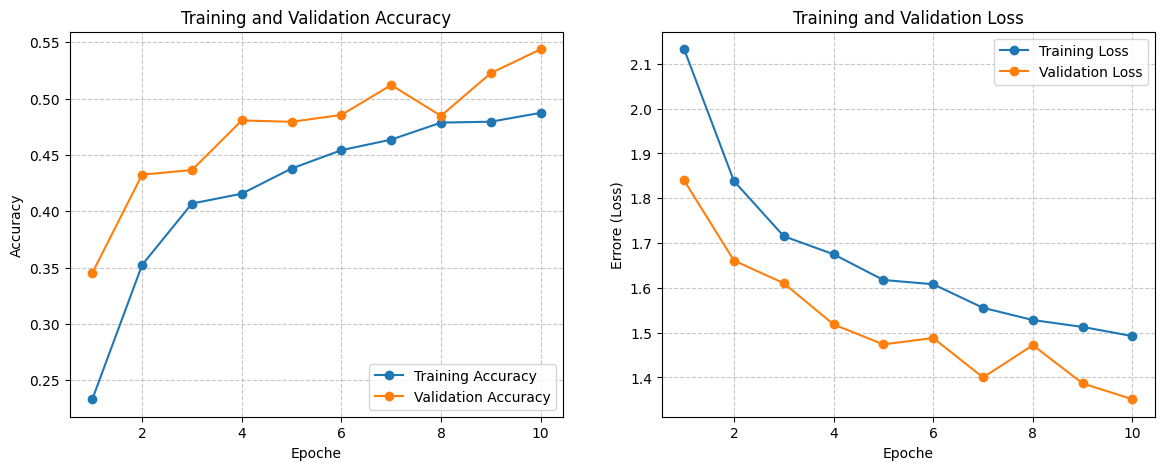

In [16]:
import matplotlib.pyplot as plt

# extracting accuracy and loss data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# create a figure with the graphs one next to the other
plt.figure(figsize=(14, 5))

# Accuracy graph (the most i goes up the better it is)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss graph (the most it goes down the better is it)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('Errore (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Training of Model 2 (Learning Rate = 0.0001)...
Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.2479 - loss: 2.1020 - val_accuracy: 0.3537 - val_loss: 1.8542
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3408 - loss: 1.8918 - val_accuracy: 0.4109 - val_loss: 1.7136
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.3747 - loss: 1.7879 - val_accuracy: 0.4667 - val_loss: 1.6020


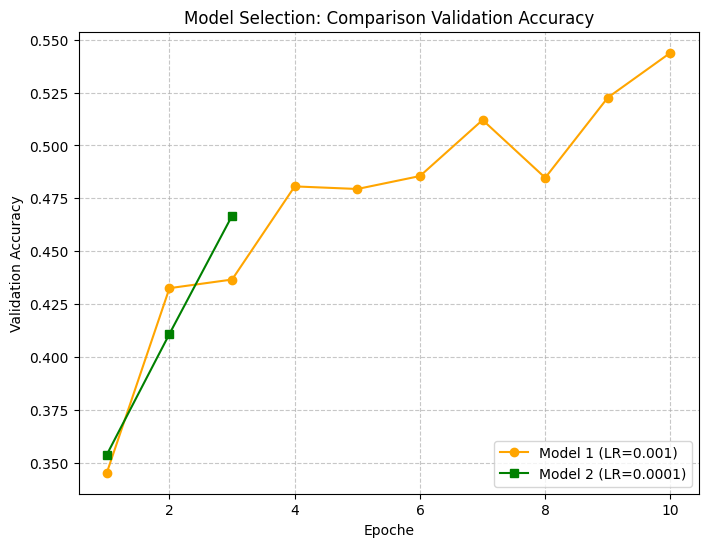

In [21]:
print("Training of Model 2 (Learning Rate = 0.0001)...")

# Creating the same neural network
model_2 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Changing the hyperparameter: Learning Rate from 0.001 to 0.0001
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training the second model
history_2 = model_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stopping],
    verbose=1
)

# Final comparison

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Model 1 (LR=0.001)', marker='o', color='orange')
plt.plot(range(1, len(history_2.history['val_accuracy']) + 1), history_2.history['val_accuracy'], label='Model 2 (LR=0.0001)', marker='s', color='green')

plt.title('Model Selection: Comparison Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()